<a href="https://colab.research.google.com/github/HTKhuongNinh-FPTU/DS-AI-Project/blob/main/MLP_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

model 5

In [8]:
from google.colab import files
uploaded = files.upload()

Saving freshretailnet_city03_dataset.csv to freshretailnet_city03_dataset (4).csv


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import hamming_loss, accuracy_score
from sklearn.neural_network import MLPClassifier

In [10]:
df = pd.read_csv('/content/freshretailnet_city03_dataset.csv')
def safe_eval_and_slice(x):
    try:
        full_list = ast.literal_eval(x);
        return full_list[6:22]
    except:
        return [0] * 16
hours_sliced_list = df['hours_stock_status'].apply(safe_eval_and_slice).tolist()
operating_hours_names = [f'hour_{i}' for i in range(6, 22)]
y_hours_df = pd.DataFrame(hours_sliced_list, columns=operating_hours_names)
print("Cấu trúc ma trận mục tiêu Y mới (Đúng 16 khung giờ hoạt động):", y_hours_df.shape)
y_hours_df.head()

Cấu trúc ma trận mục tiêu Y mới (Đúng 16 khung giờ hoạt động): (238320, 16)


,hour_6,hour_7,hour_8,hour_9,hour_10,hour_11,hour_12,hour_13,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21
0,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1
1,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1
2,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1
3,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1
4,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1,1


In [11]:
features = [
    'store_id',
    'management_group_id',
    'first_category_id',
    'second_category_id',
    'third_category_id',
    'product_id',
    'discount',
    'holiday_flag',
    'activity_flag',
    'precpt',
    'avg_temperature',
    'avg_humidity',
    'avg_wind_level',
    'oos_rate_lag1_day',
    'is_weekend']
# Ensure 'dt' column is datetime type
df['dt'] = pd.to_datetime(df['dt'])

X = df[features]
Y = y_hours_df

df_sorted = df.sort_values(by='dt').reset_index(drop=True)
Y_sorted = Y.loc[df_sorted.index]
unique_dates = df_sorted['dt'].dt.date.unique()
num_unique_dates = len(unique_dates)
train_days = 83
test_days = 7
if num_unique_dates < (train_days + test_days):
    print(f"Warning: Not enough unique dates for the requested split. Found {num_unique_dates} dates, need at least {train_days + test_days}.")
    train_cutoff_date = unique_dates[min(train_days - 1, num_unique_dates - test_days - 1)]
else:
    train_cutoff_date = unique_dates[train_days - 1]
train_indices = df_sorted[df_sorted['dt'].dt.date <= train_cutoff_date].index
test_indices = df_sorted[df_sorted['dt'].dt.date > train_cutoff_date].index

X_train = X.iloc[train_indices]
X_test = X.iloc[test_indices]
Y_train = Y.iloc[train_indices]
Y_test = Y.iloc[test_indices]

print(f"Kích thước tập huấn luyện X_train: {X_train.shape}")
print(f"Kích thước tập kiểm thử X_test: {X_test.shape}")
print(f"Số ngày huấn luyện: {len(df_sorted.loc[train_indices, 'dt'].dt.date.unique())}")
print(f"Số ngày kiểm thử: {len(df_sorted.loc[test_indices, 'dt'].dt.date.unique())}")

Kích thước tập huấn luyện X_train: (219784, 15)
Kích thước tập kiểm thử X_test: (18536, 15)
Số ngày huấn luyện: 83
Số ngày kiểm thử: 7


In [12]:
mlp_core = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    max_iter=10,
    activation='relu',
    solver='adam',
    random_state=42,
    verbose=True,
    early_stopping=True,
    n_iter_no_change=3
)
multi_target_model = MultiOutputClassifier(mlp_core, n_jobs=-1)
multi_target_model.fit(X_train, Y_train)
print("Mô hình đã học xong quy luật vận hành của 16 tiếng hoạt động.")

Mô hình đã học xong quy luật vận hành của 16 tiếng hoạt động.


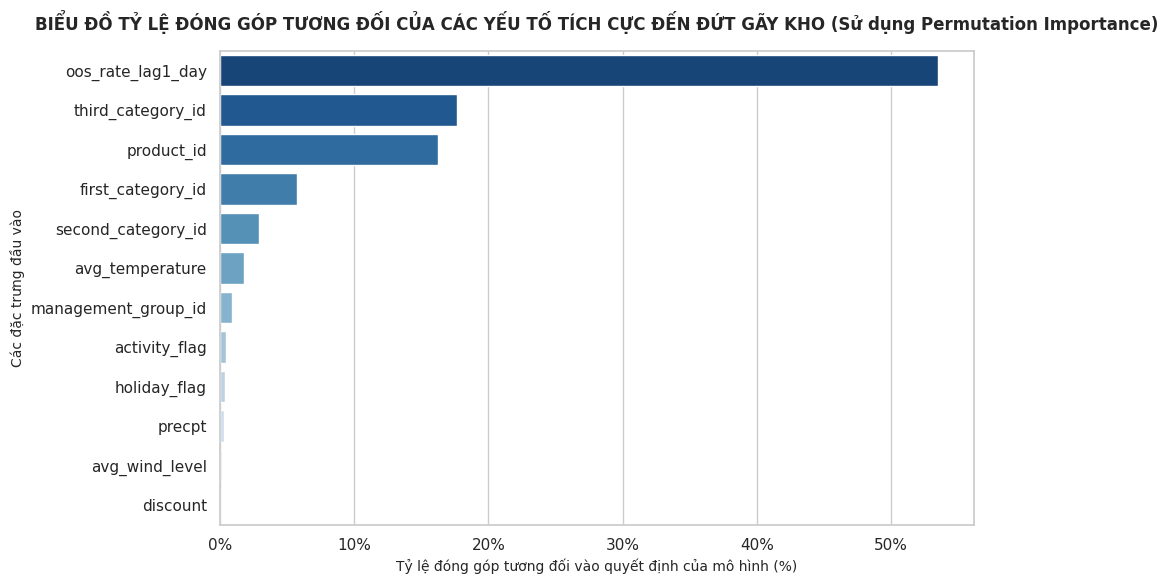

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

total_permutation_importance = np.zeros(len(features))

for i, estimator in enumerate(multi_target_model.estimators_):
    result = permutation_importance(
        estimator, X_test, Y_test.iloc[:, i],
        n_repeats=5,
        random_state=42,
        n_jobs=-1,
        scoring='f1'
    )
    total_permutation_importance += result.importances_mean

avg_importance = total_permutation_importance / len(multi_target_model.estimators_)

temp_importance_df = pd.DataFrame({
    'Đặc trưng': features,
    'Mức độ đóng góp thô': avg_importance
})

positive_contributions = temp_importance_df[temp_importance_df['Mức độ đóng góp thô'] > 0].copy()

sum_positive_contributions = positive_contributions['Mức độ đóng góp thô'].sum()

if sum_positive_contributions > 0:
    positive_contributions['Mức độ đóng góp'] = positive_contributions['Mức độ đóng góp thô'] / sum_positive_contributions
else:
    positive_contributions['Mức độ đóng góp'] = 0

importance_df = positive_contributions.sort_values(by='Mức độ đóng góp', ascending=False)


plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

sns.barplot(x='Mức độ đóng góp', y='Đặc trưng', data=importance_df, hue='Đặc trưng', palette='Blues_r', legend=False)

import matplotlib.ticker as mtick
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.title('BIỂU ĐỒ TỶ LỆ ĐÓNG GÓP TƯƠNG ĐỐI CỦA CÁC YẾU TỐ TÍCH CỰC ĐẾN ĐỨT GÃY KHO (Sử dụng Permutation Importance)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Tỷ lệ đóng góp tương đối vào quyết định của mô hình (%)', fontsize=10)
plt.ylabel('Các đặc trưng đầu vào', fontsize=10)
plt.tight_layout()
plt.show()

In [14]:
from sklearn.metrics import precision_recall_curve

y_pred_proba_list = multi_target_model.predict_proba(X_test)

best_thresholds = []
for i in range(16):
    probs = y_pred_proba_list[i][:, 1] # Xác suất lớp "Hết hàng"
    y_true = Y_test.iloc[:, i]

    # Tính Precision, Recall tại mọi ngưỡng
    precision, recall, thresholds = precision_recall_curve(y_true, probs)
    # Tính F1-Score: 2 * (P * R) / (P + R)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
    # Chọn ngưỡng tại điểm F1 cao nhất
    best_idx = np.argmax(f1_scores)
    best_thresholds.append(thresholds[best_idx])
    print(f"Giờ {i+6}h00: Ngưỡng tối ưu = {thresholds[best_idx]:.3f}")

Giờ 6h00: Ngưỡng tối ưu = 0.135
Giờ 7h00: Ngưỡng tối ưu = 0.095
Giờ 8h00: Ngưỡng tối ưu = 0.158
Giờ 9h00: Ngưỡng tối ưu = 0.343
Giờ 10h00: Ngưỡng tối ưu = 0.234
Giờ 11h00: Ngưỡng tối ưu = 0.449
Giờ 12h00: Ngưỡng tối ưu = 0.172
Giờ 13h00: Ngưỡng tối ưu = 0.375
Giờ 14h00: Ngưỡng tối ưu = 0.154
Giờ 15h00: Ngưỡng tối ưu = 0.303
Giờ 16h00: Ngưỡng tối ưu = 0.124
Giờ 17h00: Ngưỡng tối ưu = 0.017
Giờ 18h00: Ngưỡng tối ưu = 0.059
Giờ 19h00: Ngưỡng tối ưu = 0.255
Giờ 20h00: Ngưỡng tối ưu = 0.219
Giờ 21h00: Ngưỡng tối ưu = 0.315


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd
optimized_thresholds = best_thresholds

y_pred_proba_list = multi_target_model.predict_proba(X_test)
Y_pred_thresholded = np.zeros((X_test.shape[0], len(operating_hours_names)))

for i, proba_hour in enumerate(y_pred_proba_list):
    Y_pred_thresholded[:, i] = (proba_hour[:, 1] >= optimized_thresholds[i]).astype(int)

Y_pred_df = pd.DataFrame(Y_pred_thresholded, columns=operating_hours_names)
Y_pred = Y_pred_thresholded
acc_list = []
precision_list = []
recall_list = []
f1_list = []
for col in operating_hours_names:
    y_true_hour = Y_test[col]
    y_pred_hour = Y_pred_df[col]
    acc_list.append(accuracy_score(y_true_hour, y_pred_hour))
    precision_list.append(precision_score(y_true_hour, y_pred_hour, zero_division=0))
    recall_list.append(recall_score(y_true_hour, y_pred_hour, zero_division=0))
    f1_list.append(f1_score(y_true_hour, y_pred_hour, zero_division=0))
acc = np.mean(acc_list)
precision = np.mean(precision_list)
recall = np.mean(recall_list)
f1 = np.mean(f1_list)
print("\n========= KẾT QUẢ KIỂM ĐỊNH MÔ HÌNH 16 TIẾNG HOẠT ĐỘNG ==========")
print(f"Tổng số ca kiểm tra (Dòng dữ liệu tập Test): {len(X_test)}")
print(f"1. Độ chính xác tổng thể (Accuracy): {acc:.2%}")
print(f"2. Độ chính xác dự báo đứt hàng (Precision): {precision:.2%}")
print(f"3. Khả năng tìm thấy ca đứt hàng (Recall): {recall:.2%}")
print(f"4. Điểm cân bằng (F1-Score): {f1:.2%}")


========= KẾT QUẢ KIỂM ĐỊNH MÔ HÌNH 16 TIẾNG HOẠT ĐỘNG ==========
Tổng số ca kiểm tra (Dòng dữ liệu tập Test): 18536
1. Độ chính xác tổng thể (Accuracy): 75.58%
2. Độ chính xác dự báo đứt hàng (Precision): 46.62%
3. Khả năng tìm thấy ca đứt hàng (Recall): 60.39%
4. Điểm cân bằng (F1-Score): 52.41%


--- Đang trực quan hóa Lưới Ma trận nhầm lẫn (Confusion Matrix Grid 4x4) ---


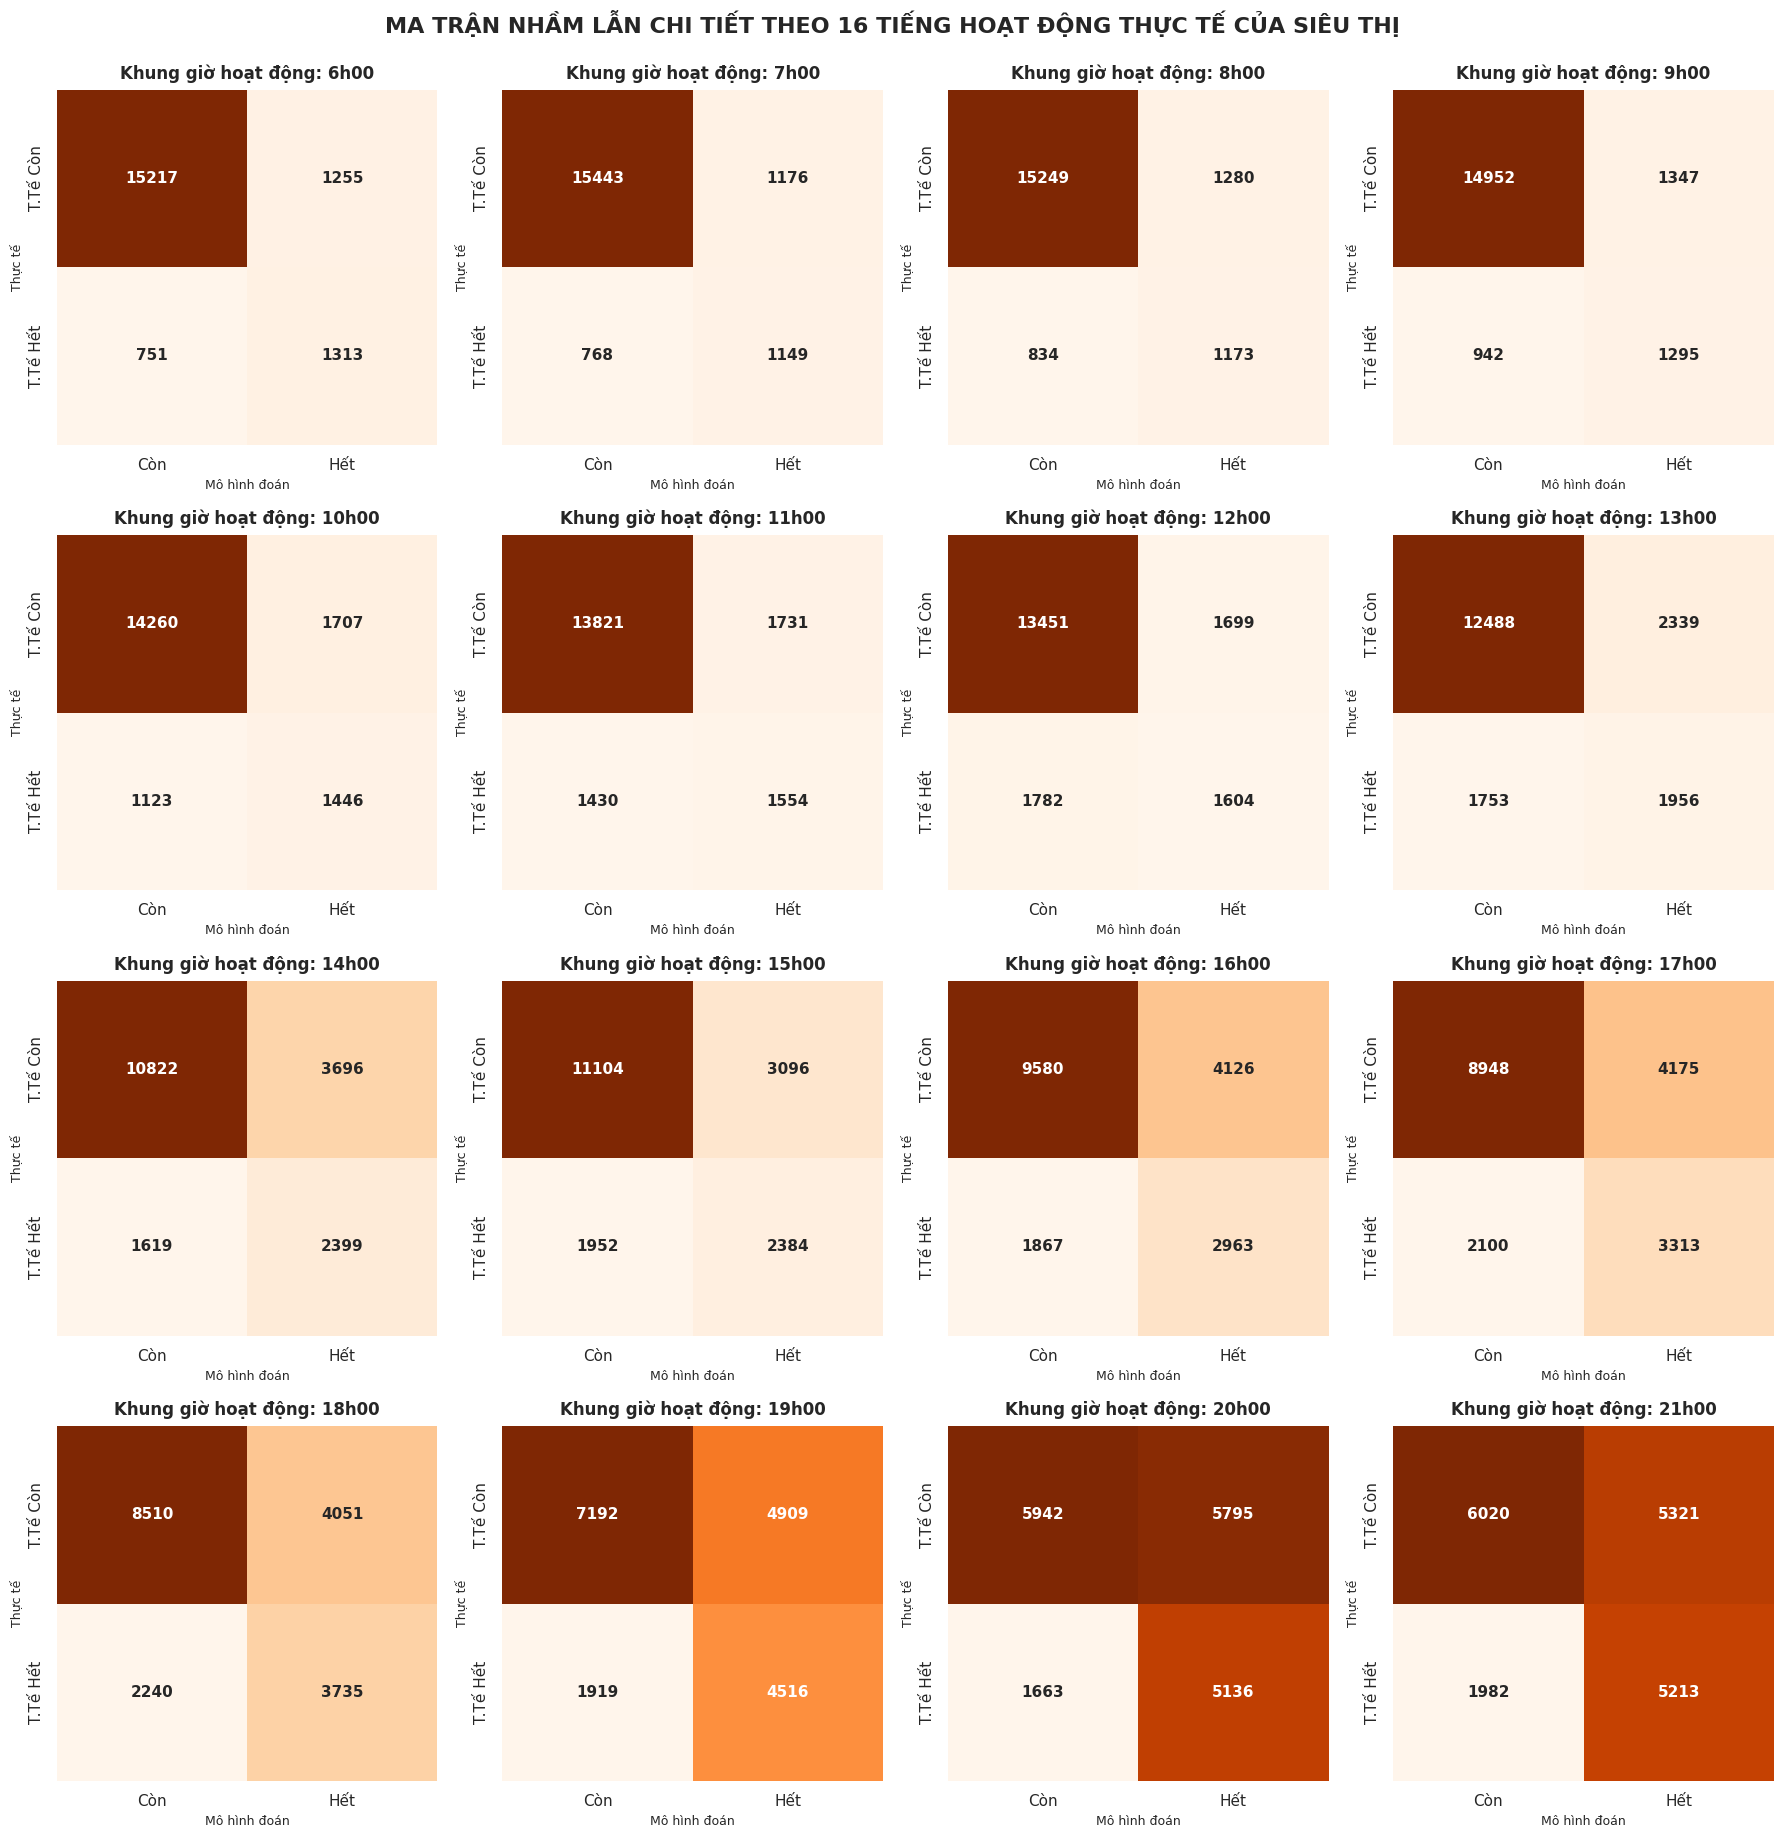

In [16]:
from sklearn.metrics import confusion_matrix
print("--- Đang trực quan hóa Lưới Ma trận nhầm lẫn (Confusion Matrix Grid 4x4) ---")
fig, axes = plt.subplots(4, 4, figsize=(18, 18))
axes = axes.flatten()
sns.set_theme(style="white")
for idx in range(16):
    col_name = operating_hours_names[idx]
    h = idx + 6
    cm = confusion_matrix(Y_test[col_name], Y_pred_df[col_name])
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Oranges',
        xticklabels=['Còn', 'Hết'],
        yticklabels=['T.Tế Còn', 'T.Tế Hết'],
        annot_kws={'size': 11, 'fontweight': 'bold'},
        cbar=False,
        ax=axes[idx])
    axes[idx].set_title(f'Khung giờ hoạt động: {h}h00', fontsize=12, fontweight='bold', pad=8)
    axes[idx].set_xlabel('Mô hình đoán', fontsize=9)
    axes[idx].set_ylabel('Thực tế', fontsize=9)
plt.tight_layout()
plt.suptitle('MA TRẬN NHẦM LẪN CHI TIẾT THEO 16 TIẾNG HOẠT ĐỘNG THỰC TẾ CỦA SIÊU THỊ',
             fontsize=16, fontweight='bold', y=1.02)
plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]

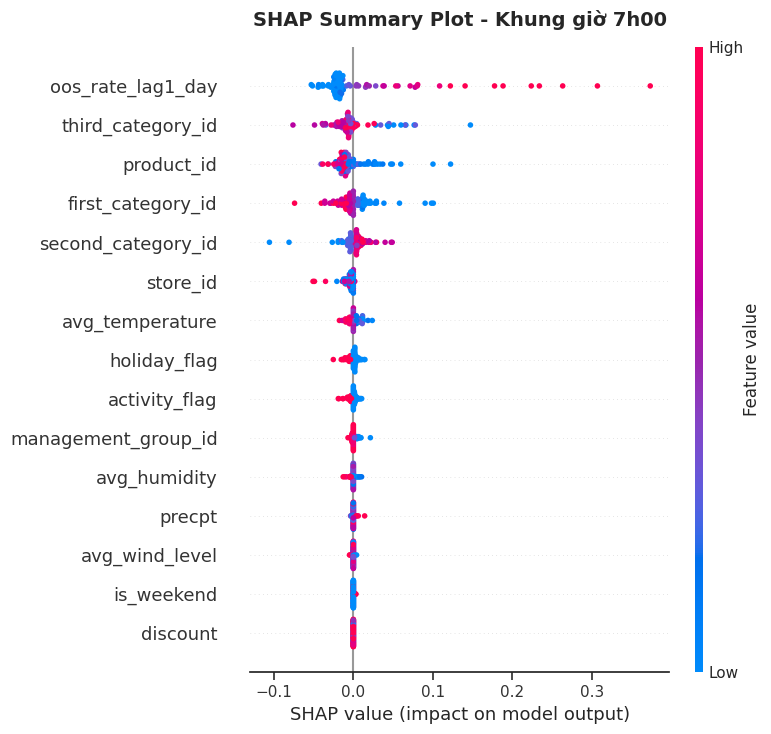

  0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

special_hours = [7, 12, 17]

feature_names = X_train.columns.tolist()

X_train_summary = shap.sample(X_train, 100)
X_test_sampled = shap.sample(X_test, 100, random_state=42)

X_train_summary_np = X_train_summary.values
X_test_sampled_np = X_test_sampled.values

for i, estimator in enumerate(multi_target_model.estimators_):
    hour = i + 6

    if hour in special_hours:
        def predict_proba_wrapper(arr):
            df_input = pd.DataFrame(arr, columns=feature_names)
            return estimator.predict_proba(df_input)[:, 1]

        explainer = shap.KernelExplainer(predict_proba_wrapper, X_train_summary_np)

        shap_values = explainer.shap_values(X_test_sampled_np)

        shap.summary_plot(shap_values, X_test_sampled_np, feature_names=feature_names, show=False)
        plt.title(f'SHAP Summary Plot - Khung giờ {hour}h00', fontsize=14, fontweight='bold', pad=15)
        plt.tight_layout()
        plt.show()